In [2]:
!jupyter nbconvert --to script "DA35 AB l4 06May2026.ipynb"

[NbConvertApp] Converting notebook DA35 AB l4 06May2026.ipynb to script
[NbConvertApp] Writing 8325 bytes to DA35 AB l4 06May2026.py


In [3]:
import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'scipy'

In [2]:
#https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing/code

data = pd.read_csv("/Users/olenaskrypka/Downloads/cookie_cats.csv")
data

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


In [3]:
basic = data[data['version']=="gate_30"]['sum_gamerounds']
test = data[data['version']=="gate_40"]['sum_gamerounds']

alpha = 0.05

observed = pd.crosstab(data['version'].values, data['sum_gamerounds'].values)

print(observed)

print(stats.chi2_contingency(observed))

statistic, pvalue, dof, expected_values = stats.chi2_contingency(observed)

print(f'chi2-statistic: {round(statistic, 2)}, p-value: {round(pvalue, 2)}')

if pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')

col_0    0      1      2      3      4      5      6      7      8      9      \
row_0                                                                           
gate_30   1937   2749   2198   1899   1831   1442   1420   1199   1162    998   
gate_40   2057   2789   2408   2059   1798   1550   1441   1180   1105   1015   

col_0    ...  2015   2063   2124   2156   2251   2294   2438   2640   2961   \
row_0    ...                                                                  
gate_30  ...      0      0      0      1      1      0      1      0      1   
gate_40  ...      1      1      1      0      0      1      0      1      0   

col_0    49854  
row_0           
gate_30      1  
gate_40      0  

[2 rows x 942 columns]
Chi2ContingencyResult(statistic=985.4980544212584, pvalue=0.1526113569373539, dof=941, expected_freq=array([[1.97952965e+03, 2.74477597e+03, 2.28285268e+03, ...,
        4.95625852e-01, 4.95625852e-01, 4.95625852e-01],
       [2.01447035e+03, 2.79322403e+03, 2.32314

Категорізація для Хі-квадрат Пірсона

Index(['sum_gamerounds', 0], dtype='object')


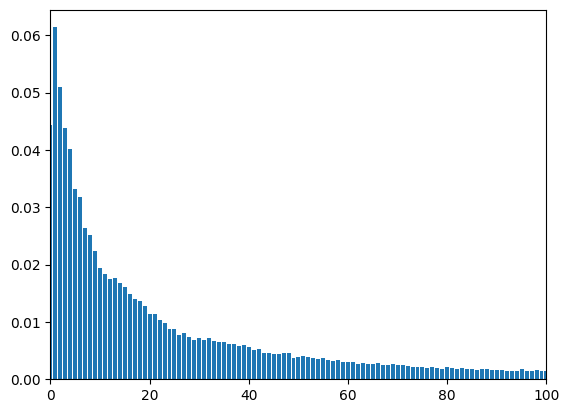

In [4]:
# Кількість входжень кожного значення sum_gamerounds

freq_table = data.groupby('sum_gamerounds').size().reset_index()

print(freq_table.columns)

freq_table['frequency'] = freq_table[0] / len(data)

plt.bar('sum_gamerounds','frequency', data=freq_table)

plt.xlim(0, 100)

plt.show()

In [5]:
data['group'] = np.where(
    (data['sum_gamerounds'] <= 9), "0"+data['sum_gamerounds'].astype(str),
    np.where(
        (data['sum_gamerounds'] >= 10) & (data['sum_gamerounds'] <= 14),'10-14',
        np.where(
            (data['sum_gamerounds'] >= 15) & (data['sum_gamerounds'] <= 20),'15-20',
                np.where(
                (data['sum_gamerounds'] >= 21) & (data['sum_gamerounds'] <= 35),'21-35',
                np.where(
                    (data['sum_gamerounds'] >= 36) & (data['sum_gamerounds'] <= 50),'36-50',
                    np.where(
                        (data['sum_gamerounds'] >= 51) & (data['sum_gamerounds'] <= 100),'51-100',
                        "other"
                    )
                )
            )
        )
    )
)

Index(['group', 0], dtype='object')


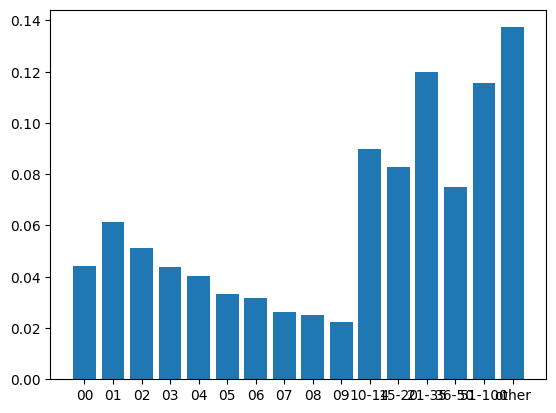

In [6]:
# Кількість входжень кожного значення sum_gamerounds


freq_table = data.groupby('group').size().reset_index()

print(freq_table.columns)

freq_table['frequency'] = freq_table[0] / len(data)

plt.bar('group','frequency', data=freq_table)
plt.show()

In [14]:
data['group2'] = np.where(
    (data['sum_gamerounds'] <= 200), "0"+data['sum_gamerounds'].astype(str),
    "other"
)

Index(['group2', 0], dtype='object')


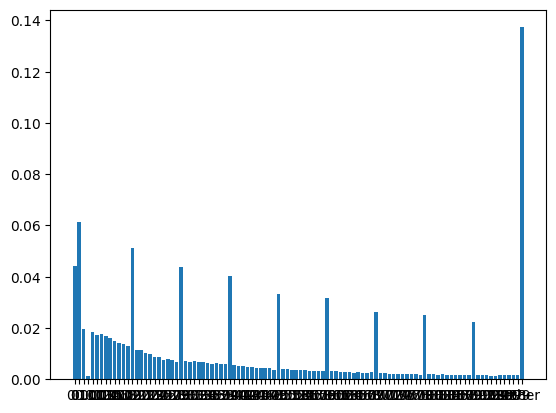

In [12]:
# Кількість входжень кожного значення sum_gamerounds


freq_table = data.groupby('group2').size().reset_index()

print(freq_table.columns)

freq_table['frequency'] = freq_table[0] / len(data)

plt.bar('group2','frequency', data=freq_table)
plt.show()

In [9]:
basic = data[data['version']=="gate_30"]['group']
test = data[data['version']=="gate_40"]['group']

alpha = 0.05

observed = pd.crosstab(data['version'].values, data['group'].values)

print(observed)

print(stats.chi2_contingency(observed))

statistic, pvalue, dof, expected_values = stats.chi2_contingency(observed)

print(f'chi2-statistic: {round(statistic, 2)}, p-value: {round(pvalue, 2)}')

if pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')

col_0      00    01    02    03    04    05    06    07    08    09  10-14  \
row_0                                                                        
gate_30  1937  2749  2198  1899  1831  1442  1420  1199  1162   998   3947   
gate_40  2057  2789  2408  2059  1798  1550  1441  1180  1105  1015   4142   

col_0    15-20  21-35  36-50  51-100  other  
row_0                                        
gate_30   3702   5457   3623    5041   6095  
gate_40   3774   5355   3140    5386   6290  
Chi2ContingencyResult(statistic=74.45783149345318, pvalue=7.09314479785542e-10, dof=15, expected_freq=array([[1979.52965439, 2744.77597046, 2282.85267605, 1961.68712371,
        1798.62621827, 1482.91255031, 1417.98556365, 1179.0939028 ,
        1123.58380734,  997.69484083, 4009.11751987, 3705.29887237,
        5358.7067159 , 3351.91763962, 5167.89076273, 6138.32618169],
       [2014.47034561, 2793.22402954, 2323.14732395, 1996.31287629,
        1830.37378173, 1509.08744969, 1443.01443635, 1199.90

In [15]:
basic = data[data['version']=="gate_30"]['group2']
test = data[data['version']=="gate_40"]['group2']

alpha = 0.05

observed = pd.crosstab(data['version'].values, data['group2'].values)

print(observed)

print(stats.chi2_contingency(observed))

statistic, pvalue, dof, expected_values = stats.chi2_contingency(observed)

print(f'chi2-statistic: {round(statistic, 2)}, p-value: {round(pvalue, 2)}')

if pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')

col_0      00    01  010  0100  0101  0102  0103  0104  0105  0106  ...  091  \
row_0                                                               ...        
gate_30  1937  2749  838    73    65    48    48    44    52    57  ...   70   
gate_40  2057  2789  914    58    60    58    77    74    60    73  ...   78   

col_0    092  093  094  095  096  097  098  099  other  
row_0                                                   
gate_30   58   63   53   84   65   57   67   67   2605  
gate_40   76   67   73   77   70   80   72   66   2618  

[2 rows x 202 columns]
Chi2ContingencyResult(statistic=303.4624992303578, pvalue=3.9851372253130295e-06, dof=201, expected_freq=array([[1979.52965439, 2744.77597046,  868.33649336,   64.92698666,
          61.95323155,   52.53634035,   61.95323155,   58.48385058,
          55.51009547,   64.43136081,   59.97072814,   51.04946279,
          56.00572132,  819.76515983,   48.57133353,   56.50134717,
          58.48385058,   52.53634035,   54.5188437

/var/folders/6t/lnq4ygr14hg_2_fpjjn0r6dm0000gn/T/ipykernel_63658/3246978022.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x=data['version'],


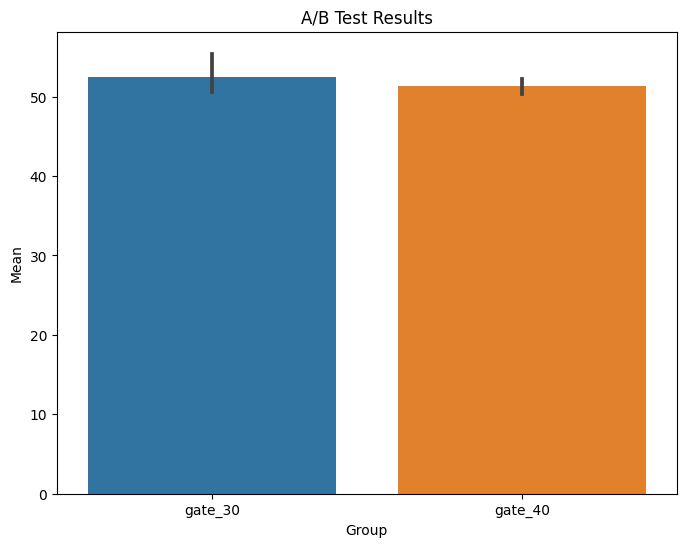

In [16]:
plt.figure(figsize=(8, 6))
sns.barplot(x=data['version'], 
            y=data['sum_gamerounds'], 
            ci = 95 # Confidence Intervals для значення алфа = 5%
           )

plt.title('A/B Test Results')
plt.xlabel('Group')
plt.ylabel('Mean')

plt.show()

In [17]:
from scipy.stats import shapiro, anderson, kstest, normaltest

# Тест Шапіро-Уілка
shapiro_test = shapiro(data['sum_gamerounds'].values)
print(f'Тест Шапіро-Уілка: статистика={shapiro_test.statistic}, p-значення={shapiro_test.pvalue}')

# Тест Андерсона-Дарлінга
anderson_test = anderson(data['sum_gamerounds'].values)
print(f'Тест Андерсона-Дарлінга: статистика={anderson_test.statistic}, критичні значення={anderson_test.critical_values}')

# Тест Колмогорова-Смирнова
kstest_test = kstest(data['sum_gamerounds'].values, 'norm')
print(f'Тест Колмогорова-Смирнова: статистика={kstest_test.statistic}, p-значення={kstest_test.pvalue}')

# Тест Д'Агостіно
dagostino_test = normaltest(data['sum_gamerounds'].values)
print(f'Тест Д\'Агостіно: статистика={dagostino_test.statistic}, p-значення={dagostino_test.pvalue}')

Тест Шапіро-Уілка: статистика=0.1440555453300476, p-значення=0.0
Тест Андерсона-Дарлінга: статистика=18627.268033775938, критичні значення=[0.576 0.656 0.787 0.918 1.092]
Тест Колмогорова-Смирнова: статистика=0.8715607041848303, p-значення=0.0
Тест Д'Агостіно: статистика=431864.6551542215, p-значення=0.0


/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


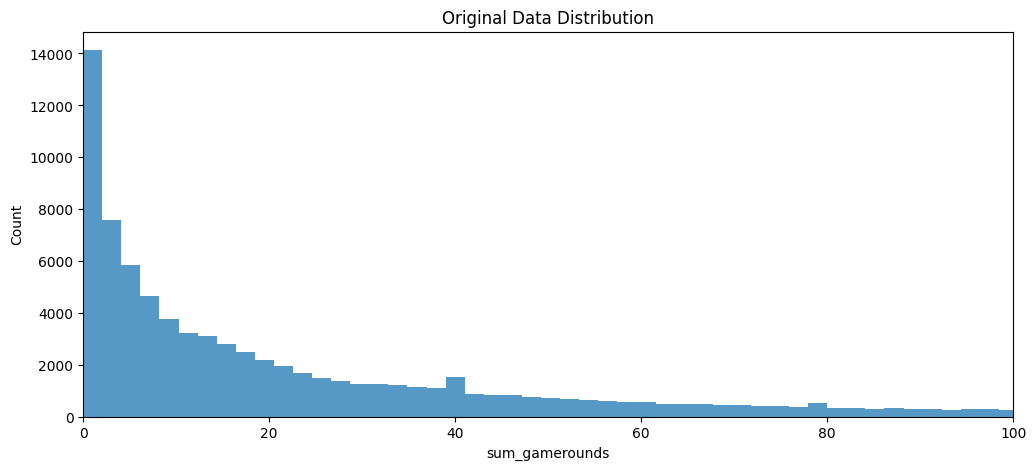

In [18]:
plt.figure(figsize=(12,5))

sns.histplot(
    data['sum_gamerounds']
)
plt.xlim(0, 100)
plt.title('Original Data Distribution')
plt.xlabel('sum_gamerounds')
plt.ylabel('Count')

plt.show()

bootstrap

In [19]:
group_A = data[data['version'] == 'gate_30']
group_B = data[data['version'] == 'gate_40']

print(len(group_A))
print(len(group_B))

44700
45489


In [22]:
subsample_A = len(group_A)
subsample_B = len(group_B)

observation = 1000

sample_average_A = []
sample_average_B = []

for i in range(subsample_A):
    sample_A = np.random.choice(group_A['sum_gamerounds'], replace=True, size=observation)
    sample_average_A.append(sample_A.mean())
    
for i in range(subsample_B):
    sample_B = np.random.choice(group_B['sum_gamerounds'], replace=True, size=observation)
    sample_average_B.append(sample_B.mean())
    
print(len(sample_average_A))
print(len(sample_average_B))

44700
45489


In [23]:
bootstrap_df = pd.DataFrame({
    'version': ['gate_30'] * len(sample_average_A) +
               ['gate_40'] * len(sample_average_B),

    'bootstrap_mean': sample_average_A + sample_average_B
})

/var/folders/6t/lnq4ygr14hg_2_fpjjn0r6dm0000gn/T/ipykernel_63658/3328586815.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x=bootstrap_df['version'],


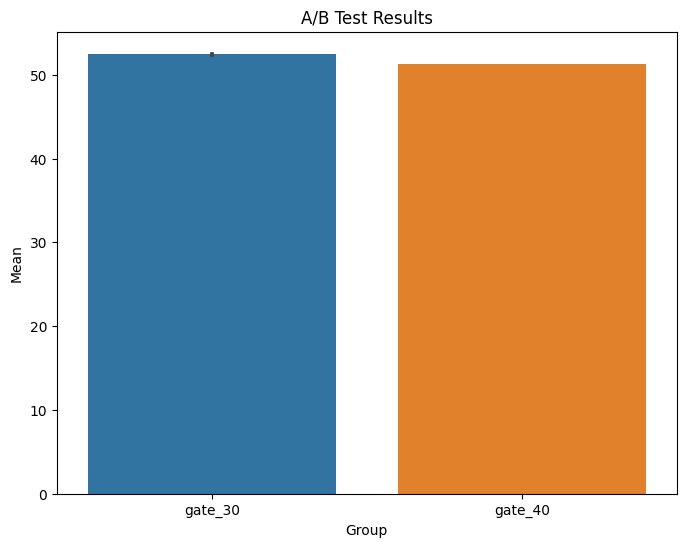

In [24]:
plt.figure(figsize=(8, 6))
sns.barplot(x=bootstrap_df['version'], 
            y=bootstrap_df['bootstrap_mean'], 
            ci = 95 # Confidence Intervals для значення алфа = 5%
           )

plt.title('A/B Test Results')
plt.xlabel('Group')
plt.ylabel('Mean')

plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


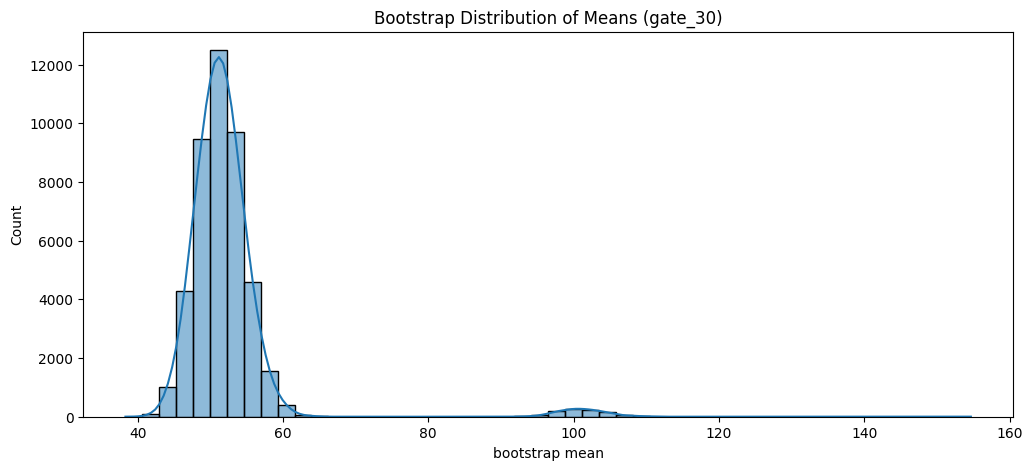

In [25]:
plt.figure(figsize=(12,5))

sns.histplot(
    sample_average_A,
    bins=50,
    kde=True
)

plt.title('Bootstrap Distribution of Means (gate_30)')
plt.xlabel('bootstrap mean')
plt.ylabel('Count')

plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


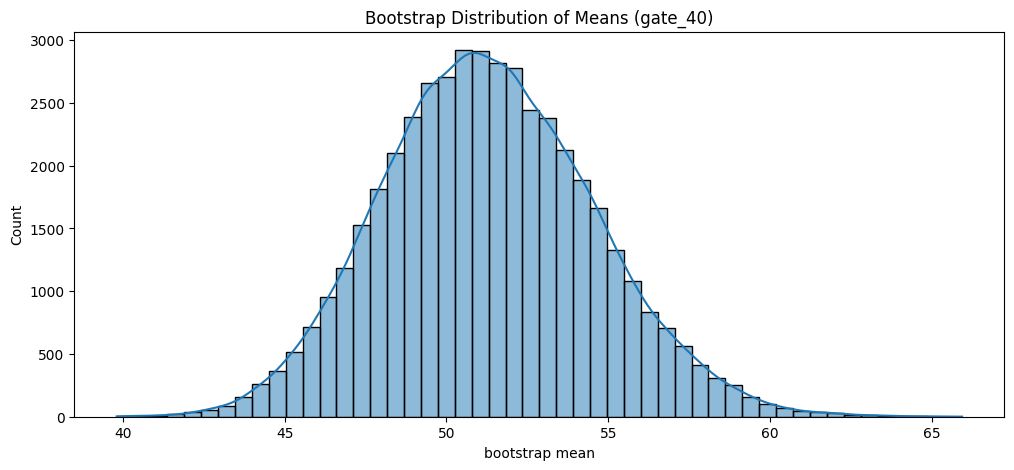

In [30]:
plt.figure(figsize=(12,5))

sns.histplot(
    sample_average_B,
    bins=50,
    kde=True
)

plt.title('Bootstrap Distribution of Means (gate_40)')
plt.xlabel('bootstrap mean')
plt.ylabel('Count')

plt.show()

In [29]:
from scipy.stats import shapiro, anderson, kstest, normaltest

# Тест Шапіро-Уілка
shapiro_test = shapiro(sample_average_B[:1000])
print(f'Тест Шапіро-Уілка: статистика={shapiro_test.statistic}, p-значення={shapiro_test.pvalue}')

# Тест Андерсона-Дарлінга
anderson_test = anderson(sample_average_B)
print(f'Тест Андерсона-Дарлінга: статистика={anderson_test.statistic}, критичні значення={anderson_test.critical_values}')

# Тест Колмогорова-Смирнова
kstest_test = kstest(sample_average_B, 'norm')
print(f'Тест Колмогорова-Смирнова: статистика={kstest_test.statistic}, p-значення={kstest_test.pvalue}')

# Тест Д'Агостіно
dagostino_test = normaltest(sample_average_B)
print(f'Тест Д\'Агостіно: статистика={dagostino_test.statistic}, p-значення={dagostino_test.pvalue}')

Тест Шапіро-Уілка: статистика=0.9974942207336426, p-значення=0.12853147089481354
Тест Андерсона-Дарлінга: статистика=17.20326636358368, критичні значення=[0.576 0.656 0.787 0.918 1.092]
Тест Колмогорова-Смирнова: статистика=1.0, p-значення=0.0
Тест Д'Агостіно: статистика=243.15759993973973, p-значення=1.5812409636894392e-53


In [31]:
def statistic_ttest(x1, y2):
    return stats.ttest_ind(x1, y2).statistic

alpha = 0.05
    
y = sample_average_A
x = sample_average_B

results = stats.permutation_test((x, y), statistic_ttest, n_resamples=500, alternative='less',)

print(results)

print(f'statistic: {round(results.statistic, 2)}, p-value: {round(results.pvalue, 2)}')

if results.pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')

PermutationTestResult(statistic=-28.078971515991647, pvalue=0.001996007984031936, null_distribution=array([-0.40701856,  1.94956102,  0.59119112, -1.83522847, -0.01185559,
        1.9828148 , -0.57607244,  0.43591565,  0.13454044,  0.23779916,
       -0.84970582, -1.19131437,  1.04905166, -1.31942896, -1.55626199,
        1.03539076,  1.31850351, -0.9375299 ,  1.71982911,  0.34369957,
        1.57707517,  0.69373418, -0.98983529,  0.40818696, -1.29962889,
        1.6128381 , -0.04383667,  0.15423732, -1.27110108, -0.351827  ,
        0.27369351,  0.02802866, -1.16951236, -1.38503425, -0.15831105,
        0.83278371, -0.32019915,  0.00769219,  0.63942396, -1.04569429,
       -0.0159957 , -1.19633621, -1.33483383,  1.37767694, -1.10849515,
       -0.37057099,  0.98003526,  0.87064373,  1.99987877, -0.03275063,
       -1.53328734,  0.96815385, -1.01053728,  0.37290623, -0.24298463,
       -0.17904403, -0.35281557, -0.71612853,  0.23170459, -1.0861973 ,
       -0.21116775, -1.16561633, -0.